# Example N27-2

Get an overview of levee charcateristics for levee trajectory 27-2.

Thanks to package `GeoProfile` that allows to visualise geotechnical data in Python.

In [1]:
import os
import pickle
import pandas as pd
import numpy as np

import datetime

import logging
logging.basicConfig(level=logging.DEBUG)
# when logging level = DEBUG, skip messages some message
for lib in ['rasterio', 'matplotlib', 'PIL', 'urllib3']:
    logging.getLogger(lib).setLevel(logging.INFO)


In [2]:
import hydropandas as hpd
hpd.__version__

'0.18.0'

In [3]:
import geoprofile
geoprofile.__version__

'0.4.0'

In [4]:
# TODO: De functies van `geolookup` staan nu allemaal in een .py bestand. Dit nog Python-ic maken. Met een init.py en verschillende sub besatanden
# TODO: geheel Object Oriented maken


In [5]:
import sys
sys.path.append(r'..\..\geolookup')
import functions as gl

In [6]:
import os
#TODO: check of nodig is, anders verwijderen
#path_to_add = r'C:\Users\HMEUW\AppData\Roaming\Python\Python313\Scripts'
#path_to_add = r'c:\Users\HMEUW\.conda\envs\wk20260129\Scripts'
#os.environ["PATH"] = path_to_add + os.pathsep + os.environ.get("PATH", "")
#print("Updated PATH:", os.environ["PATH"].split(os.pathsep)[0])

In [7]:
import os
#TODO: check of nodig is, anders verwijderen
#os.environ["KALEIDO_BROWSER_PATH"] = r"C:\Program Files\Google\Chrome\Application\chrome.exe"
#print("KALEIDO_BROWSER_PATH set to:", os.environ["KALEIDO_BROWSER_PATH"])

# Gegevens openen

In [8]:
DATA_PATH = r'N27-2_data\\'
PLOT_PATH = r'N27-2_plots\\'

In [9]:
run_longer_functions = False
write_image = False

## CPTs

Downloaded from Broloket and classified via `CPTcore` using Robertson classification.

In [10]:
# TODO: change method to plot CPTs in section perpendicular to levee. 
# Now data is projected on dikepols using Excel method to project CPTs relative to reference line (x=0)

In [11]:
region = 'Os'
dp_min = 725
dp_max = 1080
dp_max_gwl = 950 # groundwater levels in GitHub till this dp, otherwise file is too large to upload
cpt_classification = 'Robertson'

fn = DATA_PATH + f'geoprofile_columns_robertson_{region}_dp{dp_min}-{dp_max}.pkl'
logging.info(f"File last modified: {datetime.datetime.fromtimestamp(os.path.getmtime(fn)) - datetime.datetime.now()}")
with open(fn, "rb") as f:
    geoprofile_cols = pickle.load(f)
gl.describe_columns(geoprofile_cols)

INFO:root:File last modified: -2 days, 22:44:32.770738
INFO:root:Number of columns: 1248
INFO:root:Dike pole range: dp726.6 - dp1081.5, total 759 unique dike poles.
INFO:root:Data X: centered at 64380 with span 13 km, Y: centered at 397930 with span 11 km


## Hectometer indicator

In [12]:
df_hm = pd.read_csv(DATA_PATH + f'table_dijkpalen_{region}_dp{dp_min}-{dp_max}.csv')
df_hm.dp.describe()

count     711.000000
mean      902.500000
std       102.696154
min       725.000000
25%       813.750000
50%       902.500000
75%       991.250000
max      1080.000000
Name: dp, dtype: float64

## Schematised surface level of levee profiles

In [13]:
df_profile = pd.read_csv(DATA_PATH + f'table_profielen_{region}_dp{dp_min}-{dp_max}.csv')
df_profile.head()

,region,dp,ymv.bui,ysloot.1d,xmv.bin,xsloot.1a,xsloot.1c,xsloot.1d,xsloot.1b,xweg.1,...,yteen.1,yberm.1a,yberm.1b,ykruin.1,ykruin.2,yberm.2a,yberm.2b,yteen.2,yweg.2,ysloot.2
0,Os,725.0,-0.253,-0.5,-91.13,-52.13,-50.79,-50.39,-49.13,-25.13,...,1.71,6.26,6.39,6.39,6.22,4.63,4.33,0.03,0.773,-0.071
1,Os,726.0,-0.583,0.0,-200.88,-97.88,-95.77,-92.82,-90.88,-18.88,...,2.45,6.43,6.43,6.43,6.41,4.58,4.28,0.05,-0.700,-0.640
2,Os,727.0,-0.928,0.5,-51.22,-23.22,-21.81,-20.57,-19.22,-19.22,...,2.08,6.51,6.51,6.51,6.43,4.53,4.27,-0.74,-0.776,-0.776
3,Os,728.0,-0.926,0.5,-201.00,-24.00,-22.64,-22.60,-21.00,-21.00,...,1.86,6.45,6.45,6.45,6.37,4.44,4.23,0.26,-0.130,-0.929
4,Os,729.0,-1.034,0.5,-201.00,-23.62,-22.34,-20.45,-19.00,-19.00,...,1.50,6.46,6.46,6.46,6.42,4.48,4.25,-0.76,-1.046,-0.936


## Section profiles Deltaversterking

Drawings of Deltaversterking. DataFrame of distances along trajectory where drawing  is available.

In [14]:
df_section = pd.read_csv(DATA_PATH + f'table_deltaversterking_{region}_dp{dp_min}-{dp_max}.csv')
df_section['description'] = 'Deltaversterking'
df_section.dsn_file_tif = DATA_PATH + df_section.dsn_file_tif 

# column x_offset is used to shift the deltaversterking drawing in the x-direction, when x=0 is different in drawing compared to current refline.
df_section['x_offset'] = 0
df_section.loc[df_section.dp == 725.5, 'x_offset'] = -8
df_section.loc[df_section.dp == 730.5, 'x_offset'] = 3
df_section.loc[df_section.dp == 736.5, 'x_offset'] = -5
df_section.loc[df_section.dp == 744.9, 'x_offset'] = -6
df_section.loc[df_section.dp == 753.1, 'x_offset'] = -5
df_section.loc[df_section.dp == 873.2, 'x_offset'] = -5
df_section.loc[df_section.dp == 940, 'x_offset'] = 5
df_section.loc[df_section.dp == 945, 'x_offset'] = 5
df_section.loc[df_section.dp == 950, 'x_offset'] = 7
df_section.loc[df_section.dp == 953, 'x_offset'] = -8
df_section.loc[df_section.dp == 956.8, 'x_offset'] = -9
df_section.loc[df_section.dp == 961.5, 'x_offset'] = -9
df_section.loc[df_section.dp == 964, 'x_offset'] = -9
df_section.loc[df_section.dp == 968.8, 'x_offset'] = -10
df_section.loc[df_section.dp == 971.3, 'x_offset'] = -9



df_section.head()

,region,dp,dsn_file_tif,description,x_offset
0,Os,725.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking,-8
1,Os,730.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking,3
2,Os,734.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking,0
3,Os,736.5,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking,-5
4,Os,744.9,N27-2_data\\deltaversterking\os0725-0778\doors...,Deltaversterking,-6


In [15]:
if run_longer_functions:
    dp_fig = 971.3
    dp_center = 971
    fn = df_section.loc[df_section.dp == dp_fig, 'dsn_file_tif'].values[0]

    print(fn)
    from plotly.subplots import make_subplots
    import plotly.io as pio

    figure = make_subplots(
            rows=1,
            cols=1,
            horizontal_spacing=0.01,
        )

    gl.plot_deltaversterking_background(figure, fn, dp=None, fig_row=1, fig_col=1, x_offset=-9)

    gl.select_and_plot_surfacelevelprofile(dp_center, figure, df_profile, delta_dp=0, region='Os', fig_row=1, fig_col=1)

    figure.update_xaxes(range=[-30, 20], row=1, col=1)

    pio.write_html(figure, file=r'c:\temp\test.html', auto_open=True)

## Groundwater monitoring and time series
Using `HydroPandas`

In [16]:
#TODO: functie maken die ouderom netjes aangeeft, als > dag, in dagen, anders in uren, anders in minuten
fn = DATA_PATH + f'oc_gmw_{region}_dp{dp_min}-{dp_max_gwl}.pkl'
oc_gwl = hpd.read_pickle(fn)
logging.info(f"File last modified: {(datetime.datetime.fromtimestamp(os.path.getmtime(fn)) - datetime.datetime.now()).total_seconds() / 60:.2f} minutes")
gl.describe_oc(oc_gwl, expected_obs_interval=10)


INFO:root:File last modified: -46.33 minutes
INFO:root:Obs Collection has 83 monitoring wells, on 30 locations.
INFO:root:41 monitoring wells have no observations, 42 have observations.
INFO:root:First observation 2016-12-07, last observation 2025-09-30
INFO:root:Obs Collection has on average 1.2 years of observations per monitoring well, median 1.4 years. Assuming observations interval each 10 minutes.
INFO:root:Data X: centered at 63840 with span 12 km, Y: centered at 400210 with span 6 km
INFO:root:Index is unique.


# Section along the trajectory of the levee

Using the standard `profile` function of `GeoProfile`. It is called within a specific `GeoLookup` function, that creates the path.
Afterwards levee charecteristics are added to the plot. That uses the `dp` (hectometer) property of these data sets.

Section opens in a browser window. Map is included below.

INFO:root:Added 4 points to map for dps [818 819 820 821], type is <class 'pandas.core.frame.DataFrame'>.
INFO:root:Added 0 points to map for dps [818 819 820 821], type is <class 'hydropandas.obs_collection.ObsCollection'>.
Add column to profile: 100%|██████████| 8/8 [00:03<00:00,  2.34it/s]
INFO:root:Plotting 4 standpipes in figure, method=geoprofile.


82009.0 5.72
82009.0 5.67
81999.0 5.84
81999.0 5.78


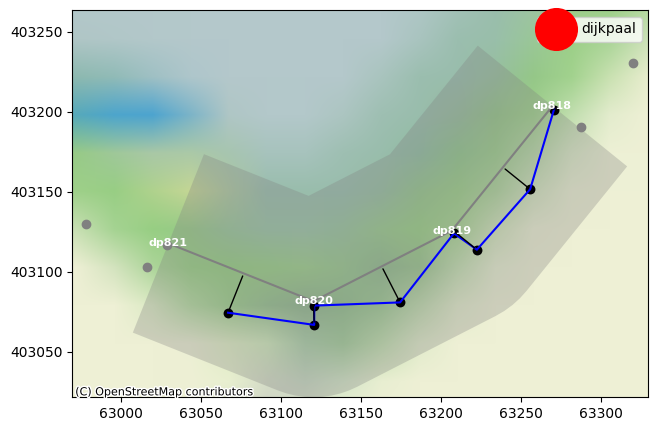

In [ ]:
if 1:
    region = 'Os'
    dp_list = np.arange(818, 821+1)
    fig, profile = gl.plot_geoprofile(
        geoprofile_cols, 
        df_hm, 
        dp_list,
        oc_gwl=oc_gwl, 
        buffer=60, 
        projectname=f"Along levee {region} {min(dp_list)}-{max(dp_list)} {cpt_classification}",
        title_suffix='',
        plot_path=PLOT_PATH,
        write_image=write_image)

In [18]:
if run_longer_functions:
    for dp_start in range(dp_min, dp_max+1, 10):
        dp_end = min(dp_start + 10, dp_max)
        dp_list = np.arange(dp_start, dp_end + 1)
        fig, profile = gl.plot_geoprofile(
            geoprofile_cols, 
            df_hm, 
            dp_list,
            oc_gwl=oc_gwl, 
            buffer=60, 
            projectname=f"Along levee {region} {min(dp_list)}-{max(dp_list)} {cpt_classification}",
            title_suffix='',
            plot_path=PLOT_PATH,
            auto_open=False,
            write_image=write_image)

In [19]:
# TODO: plotting of standpipes via oc_gwl is not working visible in maps. Annotation is plotted, legend as well. Standpipe itself not visible.

# Doorsnede maken bij dijkpaal

Een doorsnede haaks op de dijk, ter hoogte van een dijkpaal. Weergegeven wordt het beschikbare grondonderzoek, de dichtstbijzijnde versterkingstekening van de Deltaversterking, het actuele maaiveld profiel en de peilbuizen.

Informatie van meerdere dijkpalen wordt weergegeven wanneer de `delta_dp` variabele wort gebuikt. Informatie van lagere dijkpalen krijgt een rode tint, informatie van hogere dijkpalen een blauwe.

Grondonderzoek wordt geprojecteerd ten opzichte van de referentielijn. Het wordt nooit bovenopelkaargeplot. Dan krijgt het een offset. Die offset is weergegeven tussen de haakjes in het label. Grondonderzoek van de opgevraagde raai wordt als eerste geplot, en staat dus vrijwel altijd op de juiste plek.

In [33]:
dp_center = 946
delta_dp = 1

fig, fn = gl.create_figure_for_dp(
    dp_center, 
    df_section, 
    geoprofile_cols, 
    df_profile,
    oc_gwl,
    delta_dp=delta_dp,
    plot_gwl=True,
    plot_path=PLOT_PATH,
    ylims_upper=[-4, 7],
    write_image=write_image
    )

DEBUG:root:Closest dp with Deltaversterking to 946 is 945.0, fn: es\dsn12_flipped.tif, x_offset: 5
DEBUG:root:Adding Deltaversterking background from 7\doorsnedes\dsn12_flipped.tif to figure at row 1, col 1.
DEBUG:root:Plotting column dp 946.0, distance=-37.44493771390759, plotted=[np.float64(-37.0)]
DEBUG:root:Plotting column dp 946.0, distance=10.647953258934358, plotted=[np.float64(-37.0), np.float64(11.0)]
DEBUG:root:Plotting column dp 946.0, distance=-0.5786560249619805, plotted=[np.float64(-37.0), np.float64(11.0), np.float64(-1.0)]
DEBUG:root:Plotting column dp 945.5, distance=-37.33713005032834, plotted=[np.float64(-37.0), np.float64(11.0), np.float64(-1.0), np.float64(-38.0)]
DEBUG:root:Plotting column dp 946.5, distance=-37.968229251641866, plotted=[np.float64(-37.0), np.float64(11.0), np.float64(-1.0), np.float64(-38.0), np.float64(-36.0)]
DEBUG:root:Plotting column dp 945.0, distance=-34.92768178146397, plotted=[np.float64(-37.0), np.float64(11.0), np.float64(-1.0), np.floa

Section that includes no space behind and ahead.

In [21]:
fig, fn = gl.create_figure_for_dp(
    dp_center,
    df_section, 
    geoprofile_cols, 
    df_profile,
    oc_gwl,
    delta_dp=0,
    plot_path=PLOT_PATH,
    write_image=write_image
    )

DEBUG:root:Closest dp with Deltaversterking to 820 is 818.1, fn: es\dsn10_flipped.tif, x_offset: 0
DEBUG:root:Adding Deltaversterking background from 9\doorsnedes\dsn10_flipped.tif to figure at row 1, col 1.
DEBUG:root:Plotting column dp 820.0, distance=-2.763735125639539, plotted=[np.float64(-3.0)]
DEBUG:root:Plotting column dp 820.0, distance=-14.7556743357624, plotted=[np.float64(-3.0), np.float64(-15.0)]
DEBUG:root:Closest dp with surface level profile to 820 is 820.0
DEBUG:root:gmw worden niet geplot


# Overview for standpipe analysis

Plot sections for all locations with a section or a standpipe

In [22]:
if 0:
    dp_section = df_section.loc[df_section.region == 'Os', 'dp'].values
else:
    dp_section = []
dp_section

[]

In [23]:
dp_obs = oc_gwl.loc[oc_gwl.region == 'Os', 'dp'].unique()
dp_obs.sort()
dp_obs

array([738.  , 738.01, 748.99, 749.  , 761.99, 762.  , 772.  , 777.5 ,
       777.51, 781.63, 781.65, 783.02, 783.11, 784.37, 784.43, 789.01,
       789.02, 792.99, 793.  , 796.99, 819.99, 853.98, 853.99, 866.03,
       866.04, 868.67, 868.75, 869.56, 869.93, 882.04, 882.06, 893.95,
       894.  , 917.06, 917.07, 917.09, 930.5 , 931.07, 934.99, 935.02,
       940.99, 941.  , 945.99])

In [24]:
all_dps = []
for dp in [dp_section, dp_obs]:
    dp = np.round(dp).astype(int)
    dp = np.unique(dp)
    all_dps.append(dp)
# get unique values from all sublists in all_dps
unique_dps = np.unique(np.concatenate(all_dps))
unique_dps

array([738, 749, 762, 772, 778, 782, 783, 784, 789, 793, 797, 820, 854,
       866, 869, 870, 882, 894, 917, 930, 931, 935, 941, 946])

In [25]:
# from unique_dps remove values that are within 1 unit from each other
final_dps = []
for dp in unique_dps:
    if len(final_dps) == 0:
        final_dps.append(dp)
    else:
        if dp - final_dps[-1] > 1:
            final_dps.append(dp)
final_dps[:5]

[np.int64(738), np.int64(749), np.int64(762), np.int64(772), np.int64(778)]

In [30]:
run_longer_functions = True
if not run_longer_functions:
    loop_over_dps = final_dps[:2]
else:
    loop_over_dps = final_dps
    
for dp_center in loop_over_dps:
    delta_dp = 2

    fig, fn = gl.create_figure_for_dp(
        dp_center, 
        df_section, 
        geoprofile_cols, 
        df_profile,
        oc_gwl,
        delta_dp=delta_dp,
        plot_gwl=True,
        plot_path=PLOT_PATH,
        ylims_upper=[-4, 7],
        auto_open=False,
        write_image=write_image,
        )

DEBUG:root:Closest dp with Deltaversterking to 738 is 736.5, fn: des\dsn9_flipped.tif, x_offset: -5


DEBUG:root:Adding Deltaversterking background from 78\doorsnedes\dsn9_flipped.tif to figure at row 1, col 1.
DEBUG:root:Plotting column dp 738.0, distance=-16.392516335839755, plotted=[np.float64(-16.0)]
DEBUG:root:Plotting column dp 738.0, distance=9.279222057192387, plotted=[np.float64(-16.0), np.float64(9.0)]
DEBUG:root:Plotting column dp 738.0, distance=-1.4045167713055517, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0)]
DEBUG:root:Plotting column dp 737.5, distance=-16.151261177523427, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0), np.float64(-17.0)]
DEBUG:root:Plotting column dp 738.5, distance=-16.48225691616399, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0), np.float64(-17.0), np.float64(-15.0)]
DEBUG:root:Plotting column dp 737.0, distance=-15.703149688761986, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0), np.float64(-17.0), np.float64(-15.0), np.float64(-18.0)]
DEBUG:root:Plotting column dp 737.0, distance=9.89384

Section without depth limit on y-axis.

In [27]:
for dp_center in loop_over_dps:
    delta_dp = 2

    fig, fn = gl.create_figure_for_dp(
        dp_center, 
        df_section, 
        geoprofile_cols, 
        df_profile,
        oc_gwl,
        delta_dp=delta_dp,
        plot_gwl=False,
        plot_path=PLOT_PATH,
        auto_open=False,
        write_image=write_image,
        )

DEBUG:root:Closest dp with Deltaversterking to 738 is 736.5, fn: des\dsn9_flipped.tif, x_offset: -5


DEBUG:root:Adding Deltaversterking background from 78\doorsnedes\dsn9_flipped.tif to figure at row 1, col 1.
DEBUG:root:Plotting column dp 738.0, distance=-16.392516335839755, plotted=[np.float64(-16.0)]
DEBUG:root:Plotting column dp 738.0, distance=9.279222057192387, plotted=[np.float64(-16.0), np.float64(9.0)]
DEBUG:root:Plotting column dp 738.0, distance=-1.4045167713055517, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0)]
DEBUG:root:Plotting column dp 737.5, distance=-16.151261177523427, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0), np.float64(-17.0)]
DEBUG:root:Plotting column dp 738.5, distance=-16.48225691616399, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0), np.float64(-17.0), np.float64(-15.0)]
DEBUG:root:Plotting column dp 737.0, distance=-15.703149688761986, plotted=[np.float64(-16.0), np.float64(9.0), np.float64(-1.0), np.float64(-17.0), np.float64(-15.0), np.float64(-18.0)]
DEBUG:root:Plotting column dp 737.0, distance=9.89384

Probleem write

In [28]:
oc_gwl.iloc[0].position in ['KR']

True

In [ ]:
# Minimal Plotly + Kaleido test for troubleshooting
import plotly.graph_objects as go
fig = go.Figure(go.Bar(y=[2, 3, 1]))
fig.write_image("test_kaleido.png")
print("If you see test_kaleido.png in your folder, Kaleido works!")

DEBUG:kaleido.kaleido:Successfully registered PlotlyJSONEncoder.
DEBUG:asyncio:Using selector: SelectSelector
DEBUG:kaleido.kaleido:Timeout: 90
DEBUG:choreographer.browser_async:Attempting to open new browser.
INFO:choreographer.browsers.chromium:Chromium init'ed with kwargs {}
DEBUG:choreographer.browsers.chromium:Looking for a chrome browser.
DEBUG:root:Looking for browser, skipping local? False
DEBUG:root:Looking for at local chrome download path: C:\Users\HMEUW\AppData\Roaming\Python\Python313\site-packages\choreographer\cli\browser_exe\chrome-win64\chrome.exe
DEBUG:root:Local chrome not found at path: C:\Users\HMEUW\AppData\Roaming\Python\Python313\site-packages\choreographer\cli\browser_exe\chrome-win64\chrome.exe.
INFO:choreographer.browsers.chromium:Found chromium path: C:\Program Files\Google\Chrome\Application\chrome.exe
INFO:choreographer.utils._tmpfile:Temp directory created: C:\Users\HMEUW\AppData\Local\Temp\tmp5l9a_32u.
DEBUG:kaleido._page_generator:Plotly script: ('file:

RuntimeError: Did you set 0 or less tabs?

DEBUG:browser_proc:[ERROR:google_apis\gcm\engine\registration_request.cc:291] Registration response error message: PHONE_REGISTRATION_ERROR
DEBUG:browser_proc:[ERROR:google_apis\gcm\engine\registration_request.cc:291] Registration response error message: PHONE_REGISTRATION_ERROR


DEBUG:browser_proc:Created TensorFlow Lite XNNPACK delegate for CPU.
DEBUG:browser_proc:[ERROR:google_apis\gcm\engine\connection_factory_impl.cc:434] Failed to connect to MCS endpoint with error -118
DEBUG:browser_proc:[INFO:chrome\browser\extensions\extension_garbage_collector.cc:188] Garbage collection for extensions on file thread is complete.
DEBUG:browser_proc:[ERROR:google_apis\gcm\engine\registration_request.cc:291] Registration response error message: DEPRECATED_ENDPOINT
DEBUG:browser_proc:[ERROR:google_apis\gcm\engine\registration_request.cc:291] Registration response error message: DEPRECATED_ENDPOINT
DEBUG:browser_proc:[ERROR:google_apis\gcm\engine\registration_request.cc:291] Registration response error message: QUOTA_EXCEEDED
